# The task of finding the sentiment from the text

## Dataset IMDB

This is a dataset of 25,000 movie reviews from IMDB, tagged by sentiment (positive/negative). 

The reviews have been pre-processed and each review is coded as a list of word indexes (integers). 

For convenience, the words are indexed by their overall frequency in the dataset, so for example, the integer "3" encodes the third most frequent word in the data. 

This allows quick filtering operations, such as "consider only the 10,000 most frequent words, but discard the 20 most frequent words".

By convention, "0" does not indicate a specific word, but is used to encode the item token.

In [1]:
from keras.datasets import imdb
import matplotlib.pyplot as plt
import numpy as np

## Data loading
To load the data, we will use the predefined function again.

In [2]:
vocabulary_size = 5000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocabulary_size)

The first training record is displayed.

The input data is encoded as words according to the index.

In [3]:
print (x_train[0])

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 2, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 2, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 2, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 2, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 2, 19, 178, 32]


Let's see what a noodle looks like made up of words and not numbers.

First we need to download the dictionary.

In [4]:
word_idx = imdb.get_word_index()

Originally, the index number of the value is not a key.

Therefore, it is necessary to convert the index as a key and the words as values.

In [5]:
word_idx = {i: word for word, i in word_idx.items()}

Display text

In [6]:
print([word_idx[i] for i in x_train[0]])

['the', 'as', 'you', 'with', 'out', 'themselves', 'powerful', 'lets', 'loves', 'their', 'becomes', 'reaching', 'had', 'journalist', 'of', 'lot', 'from', 'anyone', 'to', 'have', 'after', 'out', 'atmosphere', 'never', 'more', 'room', 'and', 'it', 'so', 'heart', 'shows', 'to', 'years', 'of', 'every', 'never', 'going', 'and', 'help', 'moments', 'or', 'of', 'every', 'chest', 'visual', 'movie', 'except', 'her', 'was', 'several', 'of', 'enough', 'more', 'with', 'is', 'now', 'current', 'film', 'as', 'you', 'of', 'mine', 'potentially', 'unfortunately', 'of', 'you', 'than', 'him', 'that', 'with', 'out', 'themselves', 'her', 'get', 'for', 'was', 'camp', 'of', 'you', 'movie', 'sometimes', 'movie', 'that', 'with', 'scary', 'but', 'and', 'to', 'story', 'wonderful', 'that', 'in', 'seeing', 'in', 'character', 'to', 'of', '70s', 'and', 'with', 'heart', 'had', 'shadows', 'they', 'of', 'here', 'that', 'with', 'her', 'serious', 'to', 'have', 'does', 'when', 'from', 'why', 'what', 'have', 'critics', 'they'

The first review has 218 words

In [7]:
len(x_train[0])

218

Let's find out how long the reviews are.

In [8]:
print("Maximum review length: ", len(max((x_train+x_test), key=len)))
print("Minimum review length: ", len(min((x_train+x_test), key=len)))

Maximum review length:  2697
Minimum review length:  70


Now that we know what the input data looks like, let's look at the output.

The resolution can be positive (0) or negative (1)

In [9]:
print(np.unique(y_train))

[0 1]


# Data preparation
The tensorflow library has functions for working with sequences

In [10]:
from tensorflow.keras.preprocessing import sequence

We'll take the first 400 words of each review. If the review is not long enough, we fill it with a blank word or the number 0.

In [11]:
max_words = 400
 
x_train = sequence.pad_sequences(x_train, maxlen=max_words)
x_test = sequence.pad_sequences(x_test, maxlen=max_words)
 
x_valid, y_valid = x_train[:64], y_train[:64]
x_train_, y_train_ = x_train[64:], y_train[64:]

Let's check the length of the first slice, which was originally 218 characters long.

In [12]:
print (len(x_train[0]))

400


Let's take a look at the first review.

In [13]:
x_train[0]

array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,   

# Simple RNN model
For the neural network we again choose SimpleRNN

In [14]:
from keras.layers import SimpleRNN, Dense, Embedding
from keras.models import Sequential

We create a sequential model

In [15]:
RNN_model = Sequential(name="Simple_RNN")

The first layer is Embedding, it is used to map discrete values (e.g. numeric IDs of words) into dense vectors (embeddings).

It is typically used when working with text. You have a vocab_size dictionary, each word is represented by a number (an index in the dictionary).

The embedding converts this number into a fixed-length output_dim vector.

So instead of one-hot encoding, words are represented by a more compact, meaningful vector.

It is necessary to determine the size of the embedding. In our case, we set it to 32.

In [16]:
embd_len = 32
RNN_model.add(Embedding(vocabulary_size, embd_len))

Then follows the SimpleRNN network.

In [17]:
RNN_model.add(SimpleRNN(128,
                        activation='tanh',
                        return_sequences=False))

Last is the output Dense layer, which returns a number between 0 and 1.

In [18]:
RNN_model.add(Dense(1, activation='sigmoid'))

Representation of the neural network structure.

In [19]:
RNN_model.summary()

Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Learning

This is a two-class classification model, so we use the loss function binary_crossentropy.

In [20]:
RNN_model.compile(
    loss="binary_crossentropy",
    optimizer='adam',
    metrics=['accuracy']
)

We let go for learning.

In [21]:
rnn_history = RNN_model.fit(x_train_, y_train_,
                        batch_size=64,
                        epochs=10,
                        verbose=1,
                        validation_data=(x_valid, y_valid))

Epoch 1/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 42s 106ms/step - accuracy: 0.5131 - loss: 0.6974 - val_accuracy: 0.4219 - val_loss: 0.7089
Epoch 2/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 61s 52ms/step - accuracy: 0.5659 - loss: 0.6785 - val_accuracy: 0.4219 - val_loss: 0.7180
Epoch 3/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 23s 57ms/step - accuracy: 0.6252 - loss: 0.6444 - val_accuracy: 0.5938 - val_loss: 0.6717
Epoch 4/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 23s 59ms/step - accuracy: 0.6687 - loss: 0.6023 - val_accuracy: 0.6406 - val_loss: 0.6761
Epoch 5/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 23s 59ms/step - accuracy: 0.6727 - loss: 0.5885 - val_accuracy: 0.5938 - val_loss: 0.7213
Epoch 6/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 24s 62ms/step - accuracy: 0.6849 - loss: 0.5649 - val_accuracy: 0.7031 - val_loss: 0.6959
Epoch 7/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - accuracy: 0.7231 - loss: 0.5266 - val_accuracy: 0.6094 - val_loss: 0.7601
Epoch 8/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 24s 61ms/step - accuracy: 0.7800 - loss: 0.4643 -

### Saving the trained net

In [22]:
RNN_model.save('rnn_simple.keras')

### History of learning

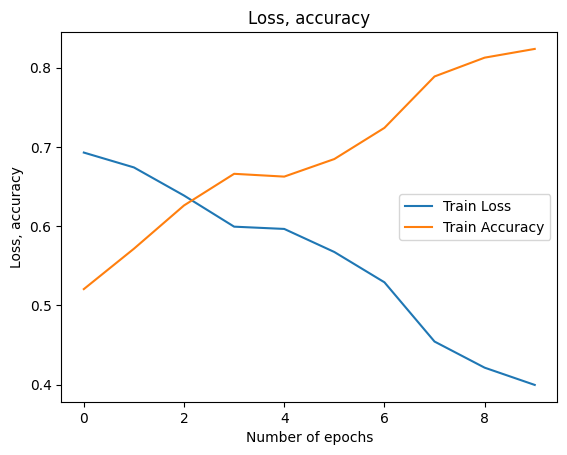

In [23]:
fig1 = plt.figure()
plt.plot(rnn_history.history['loss'], label='Train Loss')
plt.plot(rnn_history.history['accuracy'], label='Train Accuracy')
plt.legend(loc="right")
plt.title('Loss, accuracy')
plt.ylabel('Loss, accuracy')
plt.xlabel('Number of epochs')
plt.show()   

## Model validation
* The first number is the value of the cost/loss function
* The second number is the accuracy

In [24]:
RNN_model.evaluate(x_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.7561 - loss: 0.5399


[0.5274133086204529, 0.7626399993896484]

# GRU model
The model will be very similar, but we will replace the SimpleRNN part with GRU.

In [25]:
from keras.layers import GRU
gru_model = Sequential(name="GRU_Model")
gru_model.add(Embedding(vocabulary_size,
                        embd_len))
gru_model.add(GRU(128,
                  activation='tanh',
                  return_sequences=False))
gru_model.add(Dense(1, activation='sigmoid'))

Viewing the network structure

In [26]:
gru_model.summary()

Model: "GRU_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Training a neural GRU network

In [27]:
gru_model.compile(
    loss="binary_crossentropy",
    optimizer='adam',
    metrics=['accuracy']
)

In [28]:
gru_history = gru_model.fit(x_train_, y_train_,
                         batch_size=64,
                         epochs=10,
                         verbose=1,
                         validation_data=(x_valid, y_valid))

Epoch 1/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 125s 318ms/step - accuracy: 0.6033 - loss: 0.6574 - val_accuracy: 0.8750 - val_loss: 0.2908
Epoch 2/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 111s 285ms/step - accuracy: 0.8625 - loss: 0.3327 - val_accuracy: 0.8906 - val_loss: 0.2860
Epoch 3/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 133s 341ms/step - accuracy: 0.8826 - loss: 0.2853 - val_accuracy: 0.8906 - val_loss: 0.2428
Epoch 4/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 120s 307ms/step - accuracy: 0.9117 - loss: 0.2291 - val_accuracy: 0.8906 - val_loss: 0.3626
Epoch 5/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 149s 383ms/step - accuracy: 0.9317 - loss: 0.1874 - val_accuracy: 0.9219 - val_loss: 0.1876
Epoch 6/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 185s 339ms/step - accuracy: 0.9448 - loss: 0.1466 - val_accuracy: 0.8594 - val_loss: 0.3452
Epoch 7/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 109s 279ms/step - accuracy: 0.9579 - loss: 0.1180 - val_accuracy: 0.8750 - val_loss: 0.4243
Epoch 8/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 111s 284ms/step - accuracy: 0.9708 -

### Saving the trained model

In [29]:
gru_model.save('rnn_gru.keras')

### View learning history

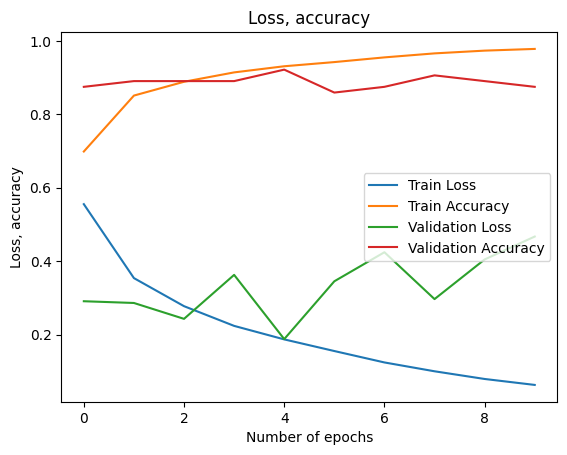

In [30]:
fig2 = plt.figure()                
plt.plot(gru_history.history['loss'], label='Train Loss')
plt.plot(gru_history.history['accuracy'], label='Train Accuracy')
plt.plot(gru_history.history['val_loss'], label='Validation Loss')
plt.plot(gru_history.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc="right")
plt.title('Loss, accuracy')
plt.ylabel('Loss, accuracy')
plt.xlabel('Number of epochs')
plt.show()   

## Model validation

In [31]:
gru_model.evaluate(x_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - accuracy: 0.8679 - loss: 0.4933


[0.47413596510887146, 0.8712000250816345]

# LTSM model
Let's try the LTSM model. Again, it only replaces a given part of the network.

In [32]:
from keras.layers import LSTM

In [33]:
lstm_model = Sequential(name="LSTM_Model")
lstm_model.add(Embedding(vocabulary_size,
                         embd_len))
lstm_model.add(LSTM(128,
                    activation='relu',
                    return_sequences=False))
lstm_model.add(Dense(1, activation='sigmoid'))

Viewing the network structure

In [34]:
lstm_model.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Neural network training

In [35]:
lstm_model.compile(
    loss="binary_crossentropy",
    optimizer='adam',
    metrics=['accuracy']
)

In [36]:
ltsm_history = lstm_model.fit(x_train_, y_train_,
                          batch_size=64,
                          epochs=10,
                          verbose=1,
                          validation_data=(x_valid, y_valid))

Epoch 1/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 98s 248ms/step - accuracy: 0.5107 - loss: nan - val_accuracy: 0.6094 - val_loss: nan
Epoch 2/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 98s 251ms/step - accuracy: 0.5071 - loss: nan - val_accuracy: 0.6094 - val_loss: nan
Epoch 3/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 97s 248ms/step - accuracy: 0.4957 - loss: nan - val_accuracy: 0.6094 - val_loss: nan
Epoch 4/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 97s 248ms/step - accuracy: 0.5035 - loss: nan - val_accuracy: 0.6094 - val_loss: nan
Epoch 5/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 96s 246ms/step - accuracy: 0.5017 - loss: nan - val_accuracy: 0.6094 - val_loss: nan
Epoch 6/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 97s 249ms/step - accuracy: 0.4980 - loss: nan - val_accuracy: 0.6094 - val_loss: nan
Epoch 7/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 97s 250ms/step - accuracy: 0.4958 - loss: nan - val_accuracy: 0.6094 - val_loss: nan
Epoch 8/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 98s 250ms/step - accuracy: 0.4957 - loss: nan - val_accuracy: 0.6094 - val_loss: nan


### View learning history

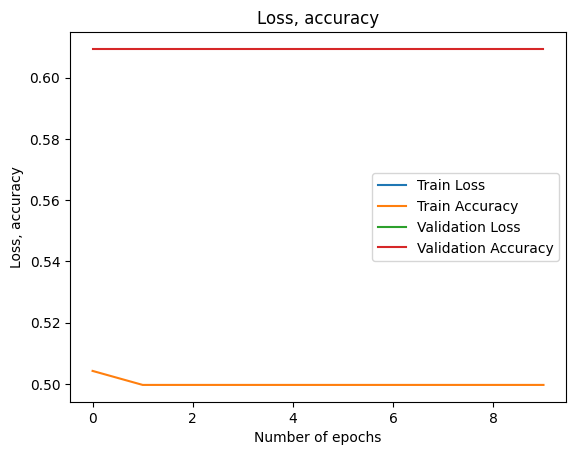

In [45]:
fig3 = plt.figure()                
plt.plot(ltsm_history.history['loss'], label='Train Loss')
plt.plot(ltsm_history.history['accuracy'], label='Train Accuracy')
plt.plot(ltsm_history.history['val_loss'], label='Validation Loss')
plt.plot(ltsm_history.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc="right")
plt.title('Loss, accuracy')
plt.ylabel('Loss, accuracy')
plt.xlabel('Number of epochs')
plt.show() 

### Saving the trained net

In [37]:
lstm_model.save('rnn_ltsm.keras')

## Model validation

In [38]:
lstm_model.evaluate(x_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 37s 47ms/step - accuracy: 0.5073 - loss: nan


[nan, 0.5]

# Bi-directional LSTM Model
For the last time we try the bi-directional LTSM model

In [40]:
from keras.layers import Bidirectional

In [41]:
bi_lstm_model = Sequential(name="Bidirectional_LSTM")
bi_lstm_model.add(Embedding(vocabulary_size,
                            embd_len))
bi_lstm_model.add(Bidirectional(LSTM(128,
                                     activation='tanh',
                                     return_sequences=False)))
bi_lstm_model.add(Dense(1, activation='sigmoid'))

Listing the network structure

In [42]:
bi_lstm_model.summary()

Model: "Bidirectional_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Training a neural network

In [43]:
bi_lstm_model.compile(
  loss="binary_crossentropy",
  optimizer='adam',
  metrics=['accuracy']
)

In [44]:
bi_lstm_history = bi_lstm_model.fit(x_train_, y_train_,
                             batch_size=64,
                             epochs=10,
                             validation_data=(x_test, y_test))

Epoch 1/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 189s 481ms/step - accuracy: 0.6569 - loss: 0.5903 - val_accuracy: 0.8524 - val_loss: 0.3511
Epoch 2/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 189s 485ms/step - accuracy: 0.8530 - loss: 0.3496 - val_accuracy: 0.8370 - val_loss: 0.3745
Epoch 3/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 199s 510ms/step - accuracy: 0.8894 - loss: 0.2742 - val_accuracy: 0.8605 - val_loss: 0.3349
Epoch 4/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 193s 496ms/step - accuracy: 0.9080 - loss: 0.2433 - val_accuracy: 0.8774 - val_loss: 0.3179
Epoch 5/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 194s 499ms/step - accuracy: 0.9224 - loss: 0.2068 - val_accuracy: 0.8773 - val_loss: 0.3144
Epoch 6/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 198s 509ms/step - accuracy: 0.9365 - loss: 0.1687 - val_accuracy: 0.7758 - val_loss: 0.5096
Epoch 7/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 195s 491ms/step - accuracy: 0.9227 - loss: 0.1958 - val_accuracy: 0.8708 - val_loss: 0.3363
Epoch 8/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 194s 499ms/step - accuracy: 0.9556 -

### Saving the trained model

In [46]:
bi_lstm_model.save('rnn_bi_ltsm.keras')

### View learning history

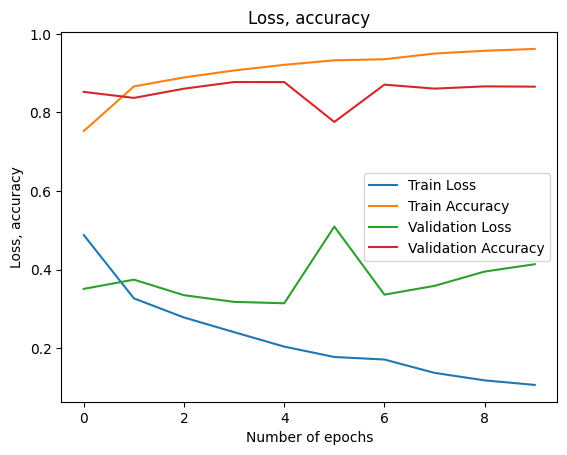

In [47]:
fig4 = plt.figure()                
plt.plot(bi_lstm_history.history['loss'], label='Train Loss')
plt.plot(bi_lstm_history.history['accuracy'], label='Train Accuracy')
plt.plot(bi_lstm_history.history['val_loss'], label='Validation Loss')
plt.plot(bi_lstm_history.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc="right")
plt.title('Loss, accuracy')
plt.ylabel('Loss, accuracy')
plt.xlabel('Number of epochs')
plt.show() 

## Model validation

In [48]:
bi_lstm_model.evaluate(x_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 52s 67ms/step - accuracy: 0.8649 - loss: 0.4203


[0.41377079486846924, 0.8656799793243408]